In [40]:
from datasets import load_dataset

dataset = load_dataset("QCRI/HumAID-all", verification_mode="no_checks")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 53531
    })
    validation: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 7793
    })
    test: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 15160
    })
})


In [43]:
from datasets import load_dataset

train_data = load_dataset(
    "QCRI/HumAID-all",
    split="train",
    verification_mode="no_checks"
)

print(train_data)

Dataset({
    features: ['tweet_text', 'class_label'],
    num_rows: 53531
})


In [9]:
print(train_data.column_names)

['tweet_text', 'class_label']


In [10]:
print(train_data[:5])

{'tweet_text': ['Powerful Ecuador quake kills at least 235: PORTOVIEJO - Rescuers in Ecuador raced to dig out people trapped un', 'Im at awe and saddened with the #EcuadorEarthquake Please any donations can help the most unfortunate!', 'RT @RachelAndJun: Our hearts are with everyone in Kumamoto and Ecuador whos been affected by these earthquakes. :( This is has been a terr', 'RT @noticias2000: Ecuador quake death toll has risen to 233. Correa just confirmed. #pedernales #ecuadorlisto', 'RT @pzf: BREAKING PHOTOS: Major damage reported in Ecuador after massive earthquake.'], 'class_label': ['injured_or_dead_people', 'rescue_volunteering_or_donation_effort', 'sympathy_and_support', 'injured_or_dead_people', 'infrastructure_and_utility_damage']}


In [11]:
print(train_data[0])

{'tweet_text': 'Powerful Ecuador quake kills at least 235: PORTOVIEJO - Rescuers in Ecuador raced to dig out people trapped un', 'class_label': 'injured_or_dead_people'}


In [12]:
print("MESSAGE:")
print(train_data[0]["tweet_text"])

print("\nCATEGORY:")
print(train_data[0]["class_label"])

MESSAGE:
Powerful Ecuador quake kills at least 235: PORTOVIEJO - Rescuers in Ecuador raced to dig out people trapped un

CATEGORY:
injured_or_dead_people


In [14]:
from collections import Counter

category_counts = Counter(train_data["class_label"])

print(category_counts)

Counter({'rescue_volunteering_or_donation_effort': 14891, 'other_relevant_information': 8501, 'sympathy_and_support': 6250, 'infrastructure_and_utility_damage': 5715, 'injured_or_dead_people': 5110, 'not_humanitarian': 4407, 'caution_and_advice': 3774, 'displaced_people_and_evacuations': 2800, 'requests_or_urgent_needs': 1833, 'missing_or_found_people': 250})


In [15]:
import pandas as pd

category_table = pd.DataFrame(
    category_counts.items(),
    columns=["Category", "Number of Messages"]
)

print(category_table.to_string(index=False))

                              Category  Number of Messages
                injured_or_dead_people                5110
rescue_volunteering_or_donation_effort               14891
                  sympathy_and_support                6250
     infrastructure_and_utility_damage                5715
              requests_or_urgent_needs                1833
            other_relevant_information                8501
                    caution_and_advice                3774
                      not_humanitarian                4407
      displaced_people_and_evacuations                2800
               missing_or_found_people                 250


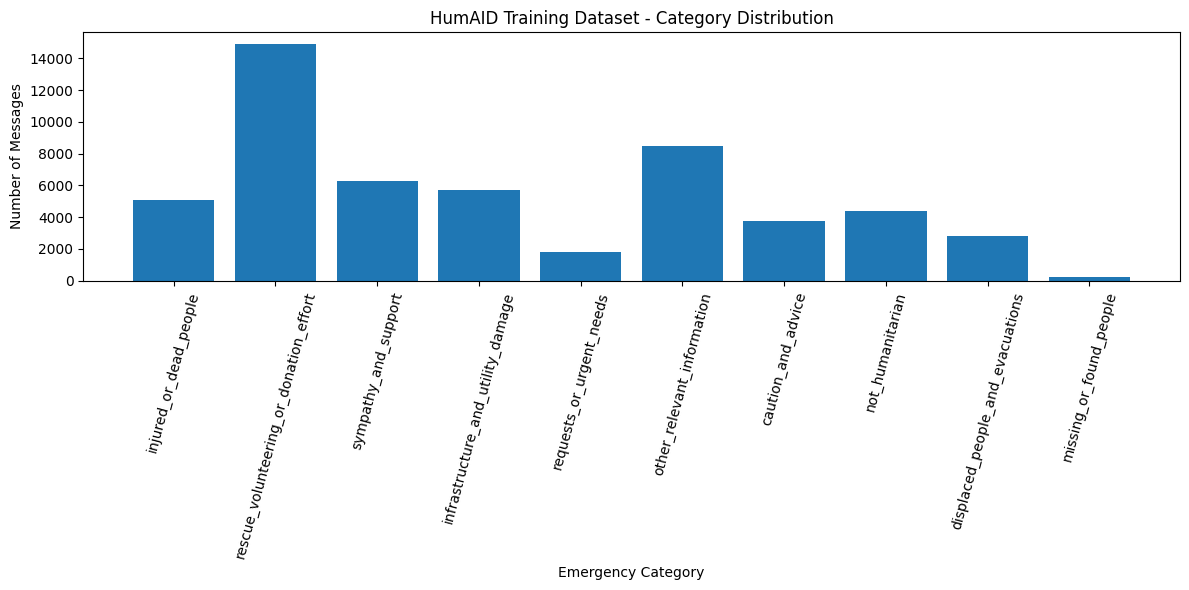

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    category_table["Category"],
    category_table["Number of Messages"]
)

plt.xticks(rotation=75)
plt.xlabel("Emergency Category")
plt.ylabel("Number of Messages")
plt.title("HumAID Training Dataset - Category Distribution")

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd

train_df = train_data.to_pandas()

print(train_df.head())

                                          tweet_text  \
0  Powerful Ecuador quake kills at least 235: POR...   
1  Im at awe and saddened with the #EcuadorEarthq...   
2  RT @RachelAndJun: Our hearts are with everyone...   
3  RT @noticias2000: Ecuador quake death toll has...   
4  RT @pzf: BREAKING PHOTOS: Major damage reporte...   

                              class_label  
0                  injured_or_dead_people  
1  rescue_volunteering_or_donation_effort  
2                    sympathy_and_support  
3                  injured_or_dead_people  
4       infrastructure_and_utility_damage  


In [18]:
print("Original message:")
print(train_df["tweet_text"].iloc[0])

Original message:
Powerful Ecuador quake kills at least 235: PORTOVIEJO - Rescuers in Ecuador raced to dig out people trapped un


In [19]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # Remove URLs
    text = re.sub(r"@\w+", "", text)             # Remove @mentions
    text = re.sub(r"\s+", " ", text).strip()     # Remove extra spaces
    return text

print("Original:")
print(train_df["tweet_text"].iloc[0])

print("\nCleaned:")
print(clean_text(train_df["tweet_text"].iloc[0]))

Original:
Powerful Ecuador quake kills at least 235: PORTOVIEJO - Rescuers in Ecuador raced to dig out people trapped un

Cleaned:
powerful ecuador quake kills at least 235: portoviejo - rescuers in ecuador raced to dig out people trapped un


In [20]:
train_df["clean_text"] = train_df["tweet_text"].apply(clean_text)

print(train_df[["tweet_text", "clean_text"]].head())

                                          tweet_text  \
0  Powerful Ecuador quake kills at least 235: POR...   
1  Im at awe and saddened with the #EcuadorEarthq...   
2  RT @RachelAndJun: Our hearts are with everyone...   
3  RT @noticias2000: Ecuador quake death toll has...   
4  RT @pzf: BREAKING PHOTOS: Major damage reporte...   

                                          clean_text  
0  powerful ecuador quake kills at least 235: por...  
1  im at awe and saddened with the #ecuadorearthq...  
2  rt : our hearts are with everyone in kumamoto ...  
3  rt : ecuador quake death toll has risen to 233...  
4  rt : breaking photos: major damage reported in...  


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(train_df["clean_text"])
y = train_df["class_label"]

print("X shape:", X.shape)
print("Y shape:", y.shape)

X shape: (53531, 10000)
Y shape: (53531,)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 42824
Testing samples: 10707


In [23]:
from sklearn.svm import LinearSVC

model = LinearSVC()

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [24]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on test data
y_pred = model.predict(X_test)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Detailed performance for each category
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7284953768562623

Classification Report:

                                        precision    recall  f1-score   support

                    caution_and_advice       0.67      0.63      0.65       755
      displaced_people_and_evacuations       0.86      0.85      0.85       560
     infrastructure_and_utility_damage       0.77      0.80      0.79      1143
                injured_or_dead_people       0.87      0.92      0.90      1022
               missing_or_found_people       0.76      0.64      0.70        50
                      not_humanitarian       0.51      0.44      0.47       882
            other_relevant_information       0.51      0.51      0.51      1700
              requests_or_urgent_needs       0.55      0.40      0.46       367
rescue_volunteering_or_donation_effort       0.80      0.87      0.83      2978
                  sympathy_and_support       0.83      0.79      0.81      1250

                              accuracy                          

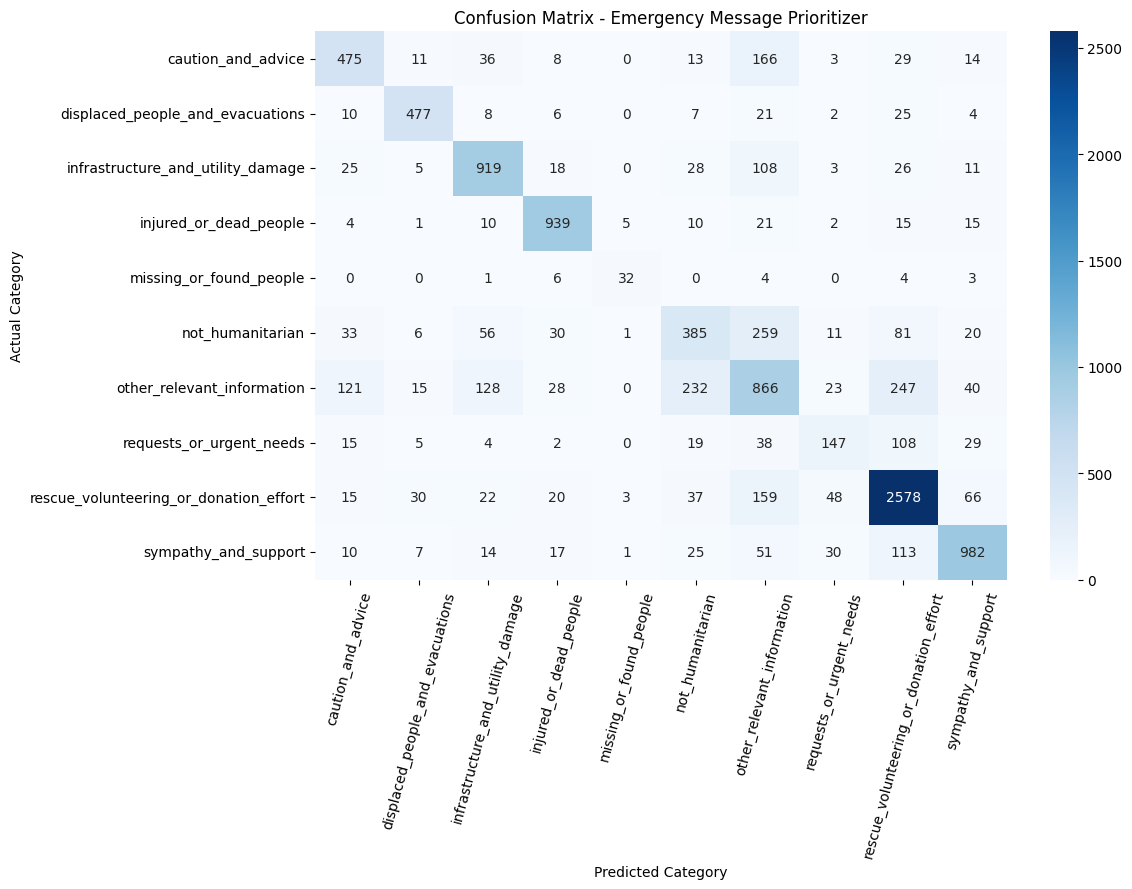

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(12, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Confusion Matrix - Emergency Message Prioritizer")

plt.xticks(rotation=75)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
def predict_category(message):
    cleaned = clean_text(message)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    return prediction

test_message = "People are trapped inside the building and need immediate rescue"

prediction = predict_category(test_message)

print("Message:")
print(test_message)

print("\nPredicted Category:")
print(prediction)

Message:
People are trapped inside the building and need immediate rescue

Predicted Category:
rescue_volunteering_or_donation_effort


In [27]:
test_messages = [
    "People are trapped inside the building and need immediate rescue.",
    "Several people were injured after the earthquake.",
    "Many families have been evacuated from the affected area.",
    "Volunteers are collecting donations to help disaster victims.",
    "Please stay indoors and follow the safety instructions."
]

for message in test_messages:
    prediction = predict_category(message)

    print("Message:", message)
    print("Predicted Category:", prediction)
    print("-" * 80)

Message: People are trapped inside the building and need immediate rescue.
Predicted Category: rescue_volunteering_or_donation_effort
--------------------------------------------------------------------------------
Message: Several people were injured after the earthquake.
Predicted Category: injured_or_dead_people
--------------------------------------------------------------------------------
Message: Many families have been evacuated from the affected area.
Predicted Category: displaced_people_and_evacuations
--------------------------------------------------------------------------------
Message: Volunteers are collecting donations to help disaster victims.
Predicted Category: rescue_volunteering_or_donation_effort
--------------------------------------------------------------------------------
Message: Please stay indoors and follow the safety instructions.
Predicted Category: caution_and_advice
--------------------------------------------------------------------------------


In [28]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

results_table = pd.DataFrame(report).transpose()

print(results_table.round(3))

                                        precision  recall  f1-score    support
caution_and_advice                          0.671   0.629     0.649    755.000
displaced_people_and_evacuations            0.856   0.852     0.854    560.000
infrastructure_and_utility_damage           0.767   0.804     0.785   1143.000
injured_or_dead_people                      0.874   0.919     0.896   1022.000
missing_or_found_people                     0.762   0.640     0.696     50.000
not_humanitarian                            0.509   0.437     0.470    882.000
other_relevant_information                  0.512   0.509     0.510   1700.000
requests_or_urgent_needs                    0.546   0.401     0.462    367.000
rescue_volunteering_or_donation_effort      0.799   0.866     0.831   2978.000
sympathy_and_support                        0.829   0.786     0.807   1250.000
accuracy                                    0.728   0.728     0.728      0.728
macro avg                                   0.713   

In [29]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

balanced_model = LinearSVC(class_weight="balanced")

balanced_model.fit(X_train, y_train)

balanced_pred = balanced_model.predict(X_test)

balanced_accuracy = accuracy_score(y_test, balanced_pred)

print("Improved Model Accuracy:", balanced_accuracy)

print("\nImproved Classification Report:\n")
print(classification_report(y_test, balanced_pred))

Improved Model Accuracy: 0.7220509946763799

Improved Classification Report:

                                        precision    recall  f1-score   support

                    caution_and_advice       0.63      0.69      0.66       755
      displaced_people_and_evacuations       0.84      0.88      0.86       560
     infrastructure_and_utility_damage       0.75      0.82      0.78      1143
                injured_or_dead_people       0.87      0.92      0.89      1022
               missing_or_found_people       0.67      0.74      0.70        50
                      not_humanitarian       0.47      0.50      0.49       882
            other_relevant_information       0.52      0.44      0.48      1700
              requests_or_urgent_needs       0.45      0.54      0.50       367
rescue_volunteering_or_donation_effort       0.84      0.82      0.83      2978
                  sympathy_and_support       0.81      0.80      0.81      1250

                              accuracy  

In [48]:
# Test our Emergency Message Prioritizer

message = input("Enter an emergency message: ")

cleaned_message = clean_text(message)

message_vector = vectorizer.transform([cleaned_message])

prediction = balanced_model.predict(message_vector)[0]

print("\nOriginal Message:", message)
print("Predicted Category:", prediction)

Enter an emergency message: people are trapped inside the building and need immediate rescue 

Original Message: people are trapped inside the building and need immediate rescue 
Predicted Category: requests_or_urgent_needs


In [33]:
# Final comparison of both models

from sklearn.metrics import accuracy_score

baseline_accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = accuracy_score(y_test, balanced_pred)

print("===== MODEL COMPARISON =====")
print("Baseline Model Accuracy :", round(baseline_accuracy * 100, 2), "%")
print("Balanced Model Accuracy :", round(balanced_accuracy * 100, 2), "%")

if balanced_accuracy > baseline_accuracy:
    print("\nBalanced model performed better.")
elif balanced_accuracy < baseline_accuracy:
    print("\nBaseline model performed better.")
else:
    print("\nBoth models have the same accuracy.")

===== MODEL COMPARISON =====
Baseline Model Accuracy : 72.85 %
Balanced Model Accuracy : 72.21 %

Baseline model performed better.


In [34]:
# Final Model Evaluation

from sklearn.metrics import classification_report

final_report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

final_results = pd.DataFrame(final_report).transpose()

print("===== FINAL MODEL PERFORMANCE =====")
print(final_results.round(3))

===== FINAL MODEL PERFORMANCE =====
                                        precision  recall  f1-score    support
caution_and_advice                          0.671   0.629     0.649    755.000
displaced_people_and_evacuations            0.856   0.852     0.854    560.000
infrastructure_and_utility_damage           0.767   0.804     0.785   1143.000
injured_or_dead_people                      0.874   0.919     0.896   1022.000
missing_or_found_people                     0.762   0.640     0.696     50.000
not_humanitarian                            0.509   0.437     0.470    882.000
other_relevant_information                  0.512   0.509     0.510   1700.000
requests_or_urgent_needs                    0.546   0.401     0.462    367.000
rescue_volunteering_or_donation_effort      0.799   0.866     0.831   2978.000
sympathy_and_support                        0.829   0.786     0.807   1250.000
accuracy                                    0.728   0.728     0.728      0.728
macro avg       

In [35]:
import joblib

artifact = {
    "model": model,
    "vectorizer": vectorizer
}

joblib.dump(artifact, "emergency_message_prioritizer.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [49]:
from google.colab import files

files.download("emergency_message_prioritizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
def emergency_message_predictor(message):
    cleaned_message = clean_text(message)
    message_vector = vectorizer.transform([cleaned_message])
    prediction = model.predict(message_vector)[0]

    print("Emergency Message:")
    print(message)

    print("\nPredicted Category:")
    print(prediction)


# Example
emergency_message_predictor(
    "Several people are trapped and need immediate rescue."
)

Emergency Message:
Several people are trapped and need immediate rescue.

Predicted Category:
requests_or_urgent_needs


In [38]:
test_messages = [
    "Many people were injured after the earthquake and need medical help.",
    "We need volunteers and donations to help disaster victims.",
    "The bridge has collapsed and roads are badly damaged."
]

for message in test_messages:
    cleaned_message = clean_text(message)
    message_vector = vectorizer.transform([cleaned_message])
    prediction = model.predict(message_vector)[0]

    print("Message:", message)
    print("Predicted Category:", prediction)
    print("-" * 70)

Message: Many people were injured after the earthquake and need medical help.
Predicted Category: requests_or_urgent_needs
----------------------------------------------------------------------
Message: We need volunteers and donations to help disaster victims.
Predicted Category: rescue_volunteering_or_donation_effort
----------------------------------------------------------------------
Message: The bridge has collapsed and roads are badly damaged.
Predicted Category: infrastructure_and_utility_damage
----------------------------------------------------------------------


In [39]:
print("==========================================")
print("   EMERGENCY MESSAGE PRIORITIZER")
print("==========================================")

print("\nDataset:")
print("HumAID Training Samples:", len(train_df))
print("Number of Categories:", len(model.classes_))

print("\nModel:")
print("Algorithm: Linear Support Vector Machine (LinearSVC)")
print("Text Features: TF-IDF")
print("N-grams: Unigrams + Bigrams")

print("\nFinal Performance:")
print("Accuracy:", round(accuracy * 100, 2), "%")
print("Macro F1-Score:", round(final_results.loc["macro avg", "f1-score"], 3))
print("Weighted F1-Score:", round(final_results.loc["weighted avg", "f1-score"], 3))

print("\nModel file:")
print("emergency_message_prioritizer.pkl")

print("\n==========================================")
print("             PROJECT COMPLETE")
print("==========================================")

   EMERGENCY MESSAGE PRIORITIZER

Dataset:
HumAID Training Samples: 53531
Number of Categories: 10

Model:
Algorithm: Linear Support Vector Machine (LinearSVC)
Text Features: TF-IDF
N-grams: Unigrams + Bigrams

Final Performance:
Accuracy: 72.85 %
Macro F1-Score: 0.696
Weighted F1-Score: 0.724

Model file:
emergency_message_prioritizer.pkl

             PROJECT COMPLETE


In [45]:
for i, cell in enumerate(_ih):
    if cell.strip():
        print(f"\nCELL {i}")
        print(cell.strip().split("\n")[0])


CELL 1
get_ipython().system('pip install -q datasets pandas scikit-learn matplotlib seaborn')

CELL 2
get_ipython().system('pip install -q datasets pandas scikit-learn matplotlib seaborn')

CELL 3
from datasets import load_dataset

CELL 4
get_ipython().system('pip install -q datasets pandas scikit-learn matplotlib seaborn')

CELL 5
from datasets import load_dataset

CELL 6
get_ipython().system('pip install -q datasets pandas scikit-learn matplotlib seaborn')

CELL 7
from datasets import load_dataset

CELL 8
from datasets import load_dataset

CELL 9
print(train_data.column_names)

CELL 10
print(train_data[:5])

CELL 11
print(train_data[0])

CELL 12
print("MESSAGE:")

CELL 13
from collections import Counter

CELL 14
from collections import Counter

CELL 15
import pandas as pd

CELL 16
import matplotlib.pyplot as plt

CELL 17
import pandas as pd

CELL 18
print("Original message:")

CELL 19
import re

CELL 20
train_df["clean_text"] = train_df["tweet_text"].apply(clean_text)

CELL 21
from 